In [1]:
import sys
from pathlib import Path

THERMOIFT_SRC = Path("../thermoift/src").resolve()
if str(THERMOIFT_SRC) not in sys.path:
    sys.path.insert(0, str(THERMOIFT_SRC))

import CoolProp.CoolProp as CP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import AutoMinorLocator
from thermoift import PLOT_SETTINGS as ps
from scipy.interpolate import UnivariateSpline

In [2]:
# ── Load high-resolution SLURM outputs ────────────────────────────
# Two SLURM jobs feed this notebook:
#   1716414           : V5 (T,P)-grid run → used for PT phase envelope only
#   1716439_bubble    : V6 branch-only run, P = P_bubble(T) - P_TOL per isotherm
#   1716445_dew       : V6 branch-only run, P = P_dew(T)    + P_TOL per isotherm
# Row order in Combined_compositions.csv matches FEED_INDEX (the array task ID).
SLURM_JOB    = '1716414'
SLURM_DIR    = Path(SLURM_JOB)
SLURM_BUBBLE = '1716439'
SLURM_DEW    = '1716445'
FEEDS_CSV    = Path('CSV_feeds/Combined_compositions.csv')

feeds = pd.read_csv(FEEDS_CSV)
n_tasks = len(feeds)
print(f"Loading {n_tasks} mixtures ...")

# Per-component TeX label (matches order used in source notebook)
_comp_tex_short = {
    'CO2': r'\mathrm{CO_2}',
    'H2':  r'\mathrm{H_2}',
    'Ar':  r'\mathrm{Ar}',
    'N2':  r'\mathrm{N_2}',
    'CH4': r'\mathrm{CH_4}',
    'O2':  r'\mathrm{O_2}',
    'CO':  r'\mathrm{CO}',
    'H2S': r'\mathrm{H_2S}',
}
_order = ['CO2', 'H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']

def feed_label(active_components_str):
    active = set(s.strip() for s in active_components_str.split(','))
    parts  = [_comp_tex_short[c] for c in _order if c in active]
    return r'$' + '+'.join(parts) + r'$'

# V5 (T,P)-grid + envelope CSVs for every task — used for PT plot only
ift_data      = {}
envelope_data = {}
labels        = {}
Tc_K          = {}
Pc_bar        = {}

# V6 branch-only: per-T γ and L90_10 at the bubble or dew saturation curve
ift_bubble = {}   # task_id -> DataFrame (T, P, gamma, interfacial_thickness, ...)
ift_dew    = {}

for k in range(n_tasks):
    ift_path = SLURM_DIR / f"{SLURM_JOB}_{k}" / "CSV" / "InterfacialProperties" / "feed_1_interfacial_results.csv"
    env_path = SLURM_DIR / f"{SLURM_JOB}_{k}" / "CSV" / "PhaseEnvelope"        / "feed_1_envelope.csv"
    ift_data[k]      = pd.read_csv(ift_path)
    envelope_data[k] = pd.read_csv(env_path)
    labels[k]        = feed_label(feeds.iloc[k]['active_components'])
    Tc_K[k]   = float(ift_data[k]['Tc'].iloc[0])
    Pc_bar[k] = float(ift_data[k]['Pc'].iloc[0])

    bub_path = Path(f"{SLURM_BUBBLE}_bubble") / f"{SLURM_BUBBLE}_{k}_bubble" / "CSV" / "InterfacialProperties" / "feed_1_interfacial_results_bubble.csv"
    dew_path = Path(f"{SLURM_DEW}_dew")       / f"{SLURM_DEW}_{k}_dew"       / "CSV" / "InterfacialProperties" / "feed_1_interfacial_results_dew.csv"
    ift_bubble[k] = pd.read_csv(bub_path).sort_values('temperature').reset_index(drop=True)
    ift_dew[k]    = pd.read_csv(dew_path).sort_values('temperature').reset_index(drop=True)

    n_T_v5 = ift_data[k]['temperature'].nunique()
    n_bub  = len(ift_bubble[k])
    n_dew  = len(ift_dew[k])
    print(f"  task {k}  n_comp={feeds.iloc[k]['mixture_size']}  V5 n_T={n_T_v5:>4d}  "
          f"V6 bubble/dew={n_bub:>3d}/{n_dew:>3d}  "
          f"Tc={Tc_K[k]:6.2f} K  Pc={Pc_bar[k]:5.1f} bar  {labels[k]}")

TASK_IDS = list(range(n_tasks))

# ColorBrewer Set1 — maximally perceptually distinct for up to 5 series
COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00'][:n_tasks]

Loading 5 mixtures ...
  task 0  n_comp=2  V5 n_T=1000  V6 bubble/dew= 99/ 99  Tc=300.47 K  Pc= 78.0 bar  $\mathrm{CO_2}+\mathrm{CO}$
  task 1  n_comp=4  V5 n_T=1013  V6 bubble/dew=101/101  Tc=301.76 K  Pc= 86.7 bar  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{CH_4}+\mathrm{H_2S}$
  task 2  n_comp=6  V5 n_T=1012  V6 bubble/dew=100/100  Tc=301.47 K  Pc= 79.0 bar  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}$
  task 3  n_comp=7  V5 n_T=1004  V6 bubble/dew=100/100  Tc=300.66 K  Pc= 84.2 bar  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}+\mathrm{CO}+\mathrm{H_2S}$
  task 4  n_comp=8  V5 n_T=1005  V6 bubble/dew=101/101  Tc=300.72 K  Pc= 80.3 bar  $\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}+\mathrm{CO}+\mathrm{H_2S}$


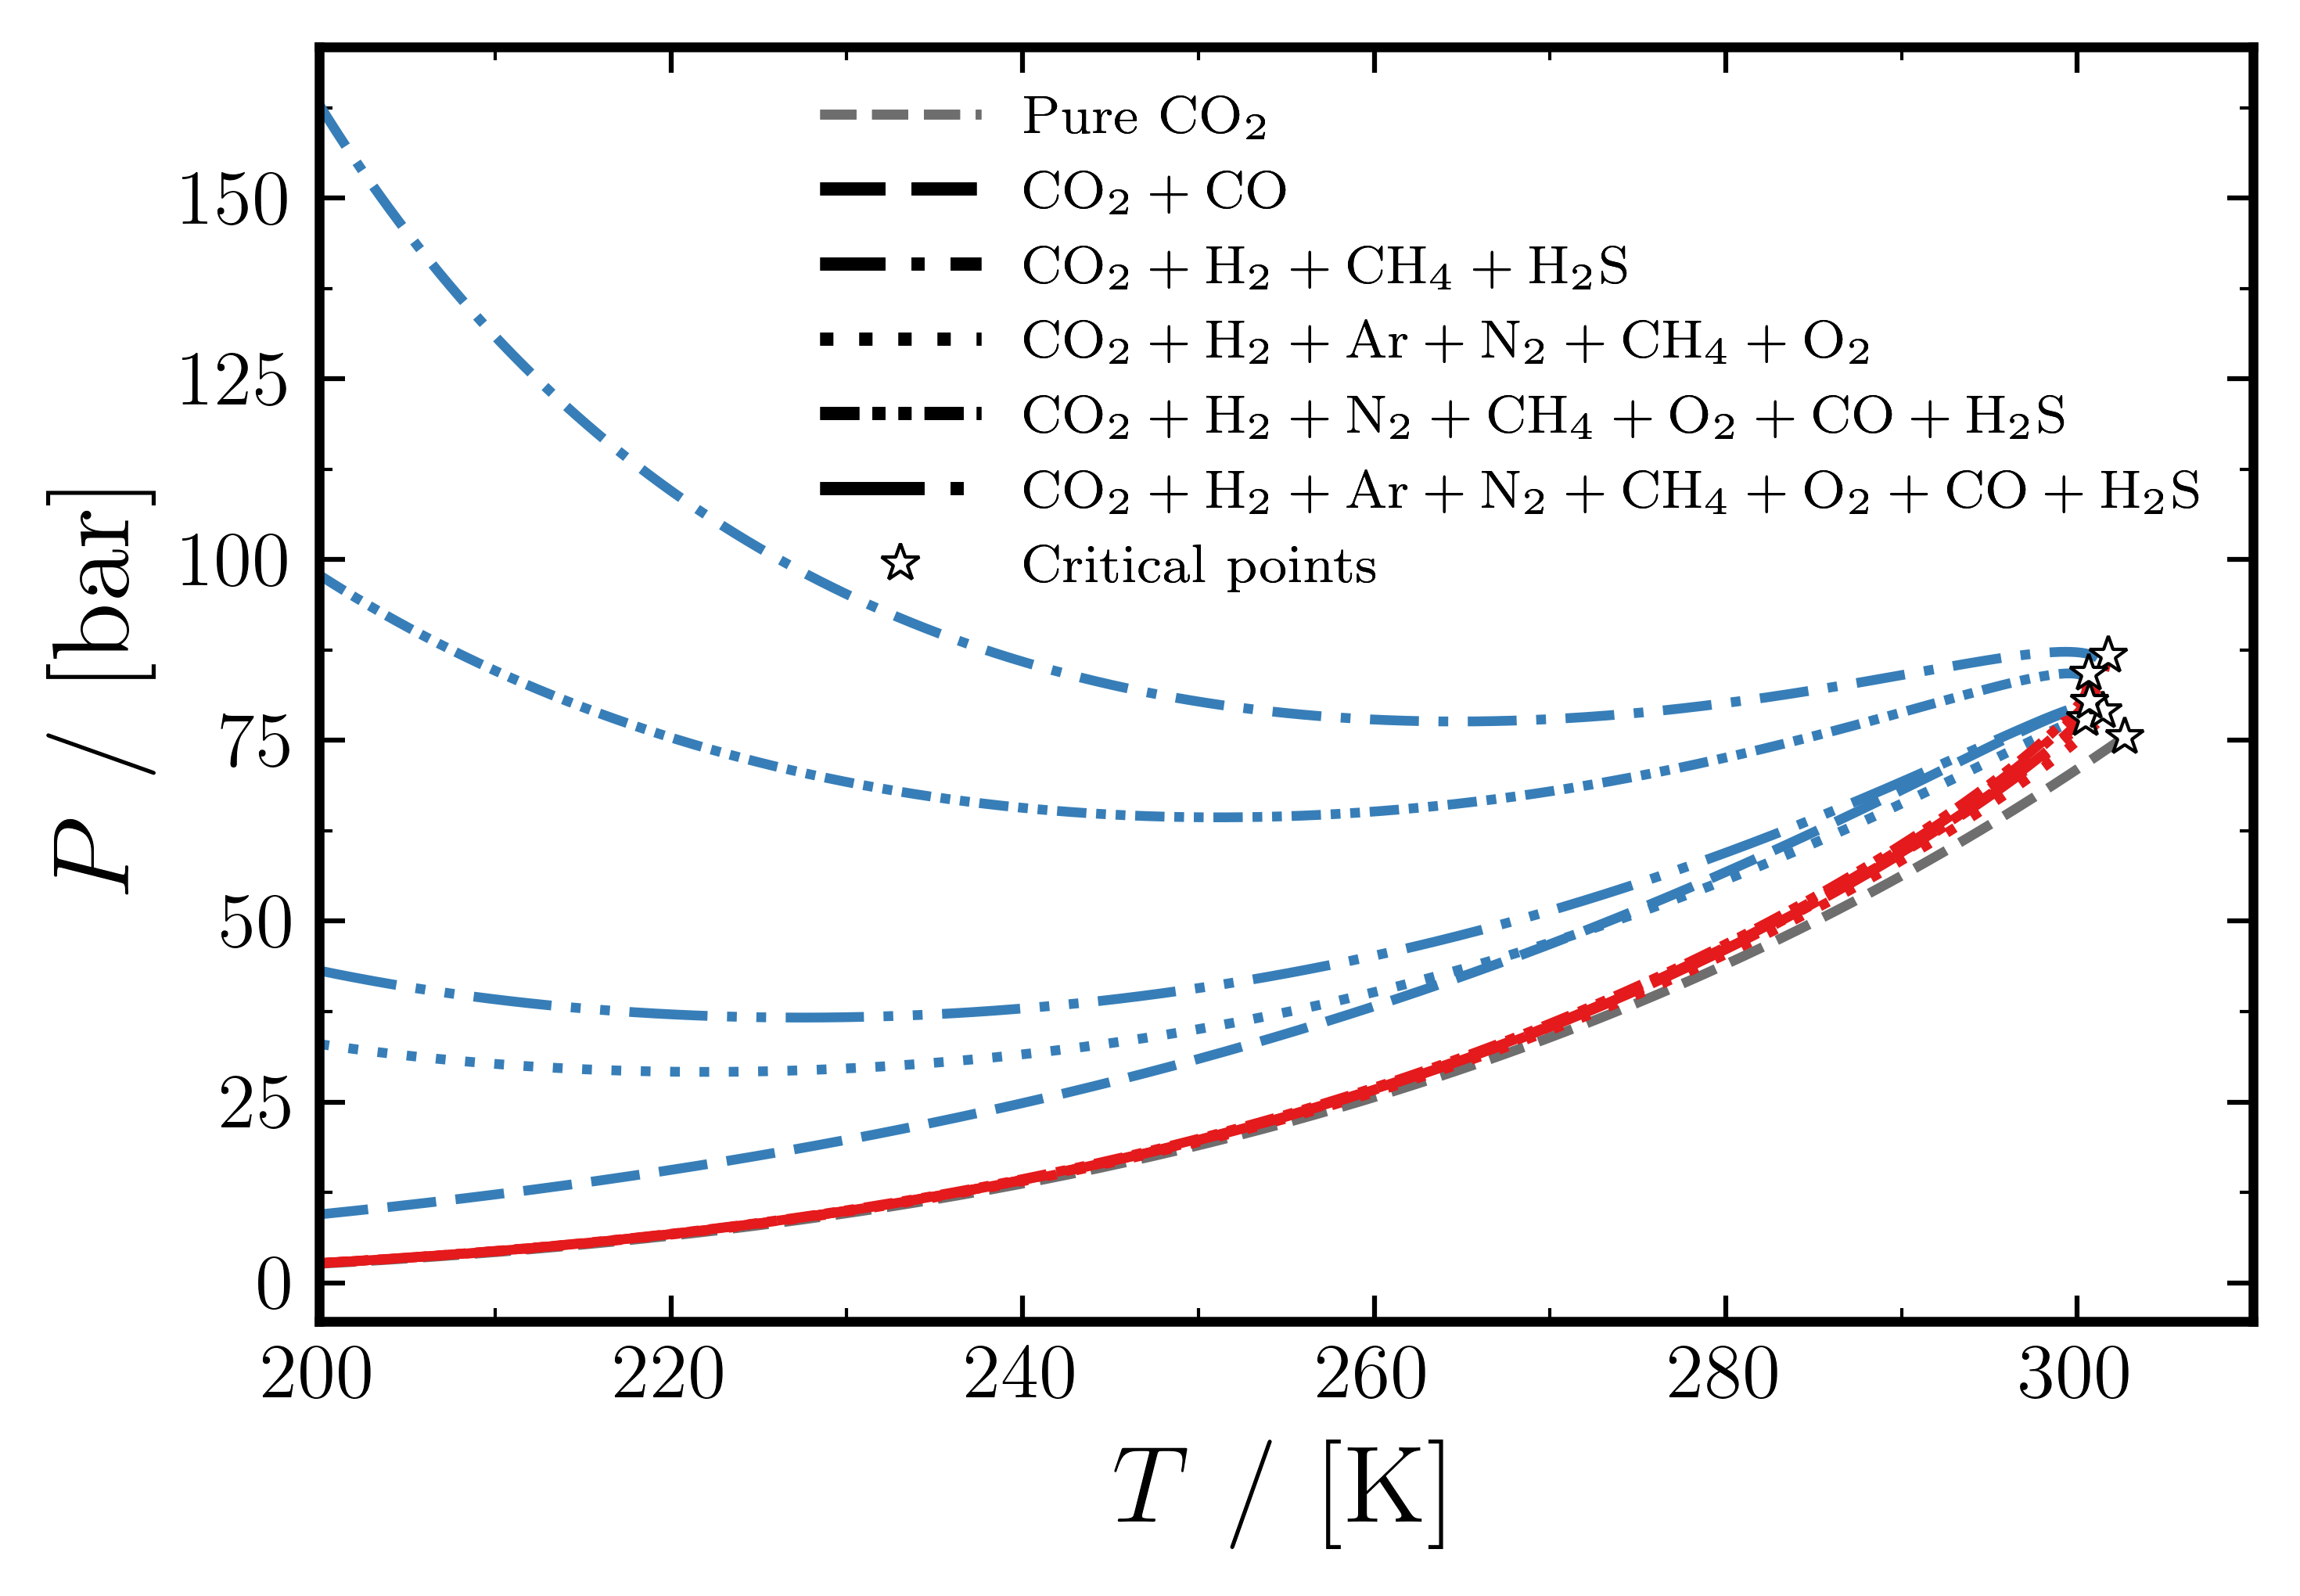

In [3]:
LINE_STYLES = [
    (0, (5, 2)),                 # dashed
    (0, (5, 2, 1, 2)),           # dash-dot
    (0, (1, 2)),                 # dotted
    (0, (3, 1, 1, 1, 1, 1)),     # dash-dot-dot
    (0, (8, 2, 1, 2, 1, 2)),     # long-dash-dot-dot
]

Tc_CO2_K   = CP.PropsSI('TCRIT', 'CO2')
Pc_CO2_bar = CP.PropsSI('PCRIT', 'CO2') / 1e5
T_co2 = np.linspace(200.0, Tc_CO2_K - 0.05, 400)
P_co2 = np.array([CP.PropsSI('P', 'T', T, 'Q', 0, 'CO2') / 1e5 for T in T_co2])

PC_SAT_CSV = Path('CO2_pcsaft_saturation.csv')
if PC_SAT_CSV.exists():
    _sat = pd.read_csv(PC_SAT_CSV)
    T_co2_pc, P_co2_pc = _sat['T_K'].to_numpy(), _sat['P_bar'].to_numpy()
    Tc_CO2_PC_K   = float(T_co2_pc[-1])
    Pc_CO2_PC_bar = float(P_co2_pc[-1])
else:
    T_co2_pc = P_co2_pc = None
    Tc_CO2_PC_K = Pc_CO2_PC_bar = None
    print(f'[warn] {PC_SAT_CSV} not found — run PURE_CO2_IFT.ipynb to generate it. '
          'PC-SAFT pure-CO2 reference will be omitted from the plot.')

fig, ax = ps.plot_init(w=5.0, h=3.5)

if T_co2_pc is not None:
    ax.plot(T_co2_pc, P_co2_pc, color='#6e6e6e', lw=1.5, ls='--', zorder=2)
    ax.plot(Tc_CO2_PC_K, Pc_CO2_PC_bar, marker='*', markersize=6,
            markerfacecolor='White', markeredgecolor='black', markeredgewidth=0.5,
            linestyle='None', zorder=6)

for k, ls in zip(TASK_IDS, LINE_STYLES):
    env = envelope_data[k].sort_values('T_K')
    bub = env[env['curve'] == 'bubble']
    dew = env[env['curve'] == 'dew']
    ax.plot(bub['T_K'], bub['P_bar'], color='#377eb8', lw=1.5, ls=ls)
    ax.plot(dew['T_K'], dew['P_bar'], color='#e41a1c', lw=1.5, ls=ls)
    # critical point — apex of the envelope
    ax.plot(Tc_K[k], Pc_bar[k], marker='*', markersize=6, markerfacecolor='white',
     markeredgecolor='black', markeredgewidth=0.5, linestyle='None', zorder=5)

src_handles = []

if T_co2_pc is not None:
    src_handles.append(
        mlines.Line2D(
            [], [],
            color='#6e6e6e', lw=1.5, ls='--',
            label=r"$\mathrm{Pure}\ \mathrm{CO}_2$"
        )
    )
src_handles += [
    mlines.Line2D([], [], color='black', lw=2.0, ls=ls, label=labels[k])
    for k, ls in zip(TASK_IDS, LINE_STYLES)
]
src_handles.append(
    mlines.Line2D([], [], marker='*', markersize=6, markerfacecolor='White',
                  markeredgecolor='black', markeredgewidth=0.5,
                  linestyle='None', label=r'$\mathrm{Critical\ points}$')
)
leg_src = ax.legend(handles=src_handles, fontsize=ps.label_fontsize/1.7, loc='upper right',
                    frameon=False, handlelength=3.0)
ax.add_artist(leg_src)

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',   fontsize=ps.label_fontsize*1.2)
ax.set_ylabel(r'$P$ $/$ $[\mathrm{bar}]$', fontsize=ps.label_fontsize*1.2)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True, labelsize=ps.tick_labelsize*1.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

plt.xlim(200, 310)
# plt.ylim(0, 190)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_PT_phase_map_hires')
plt.show()

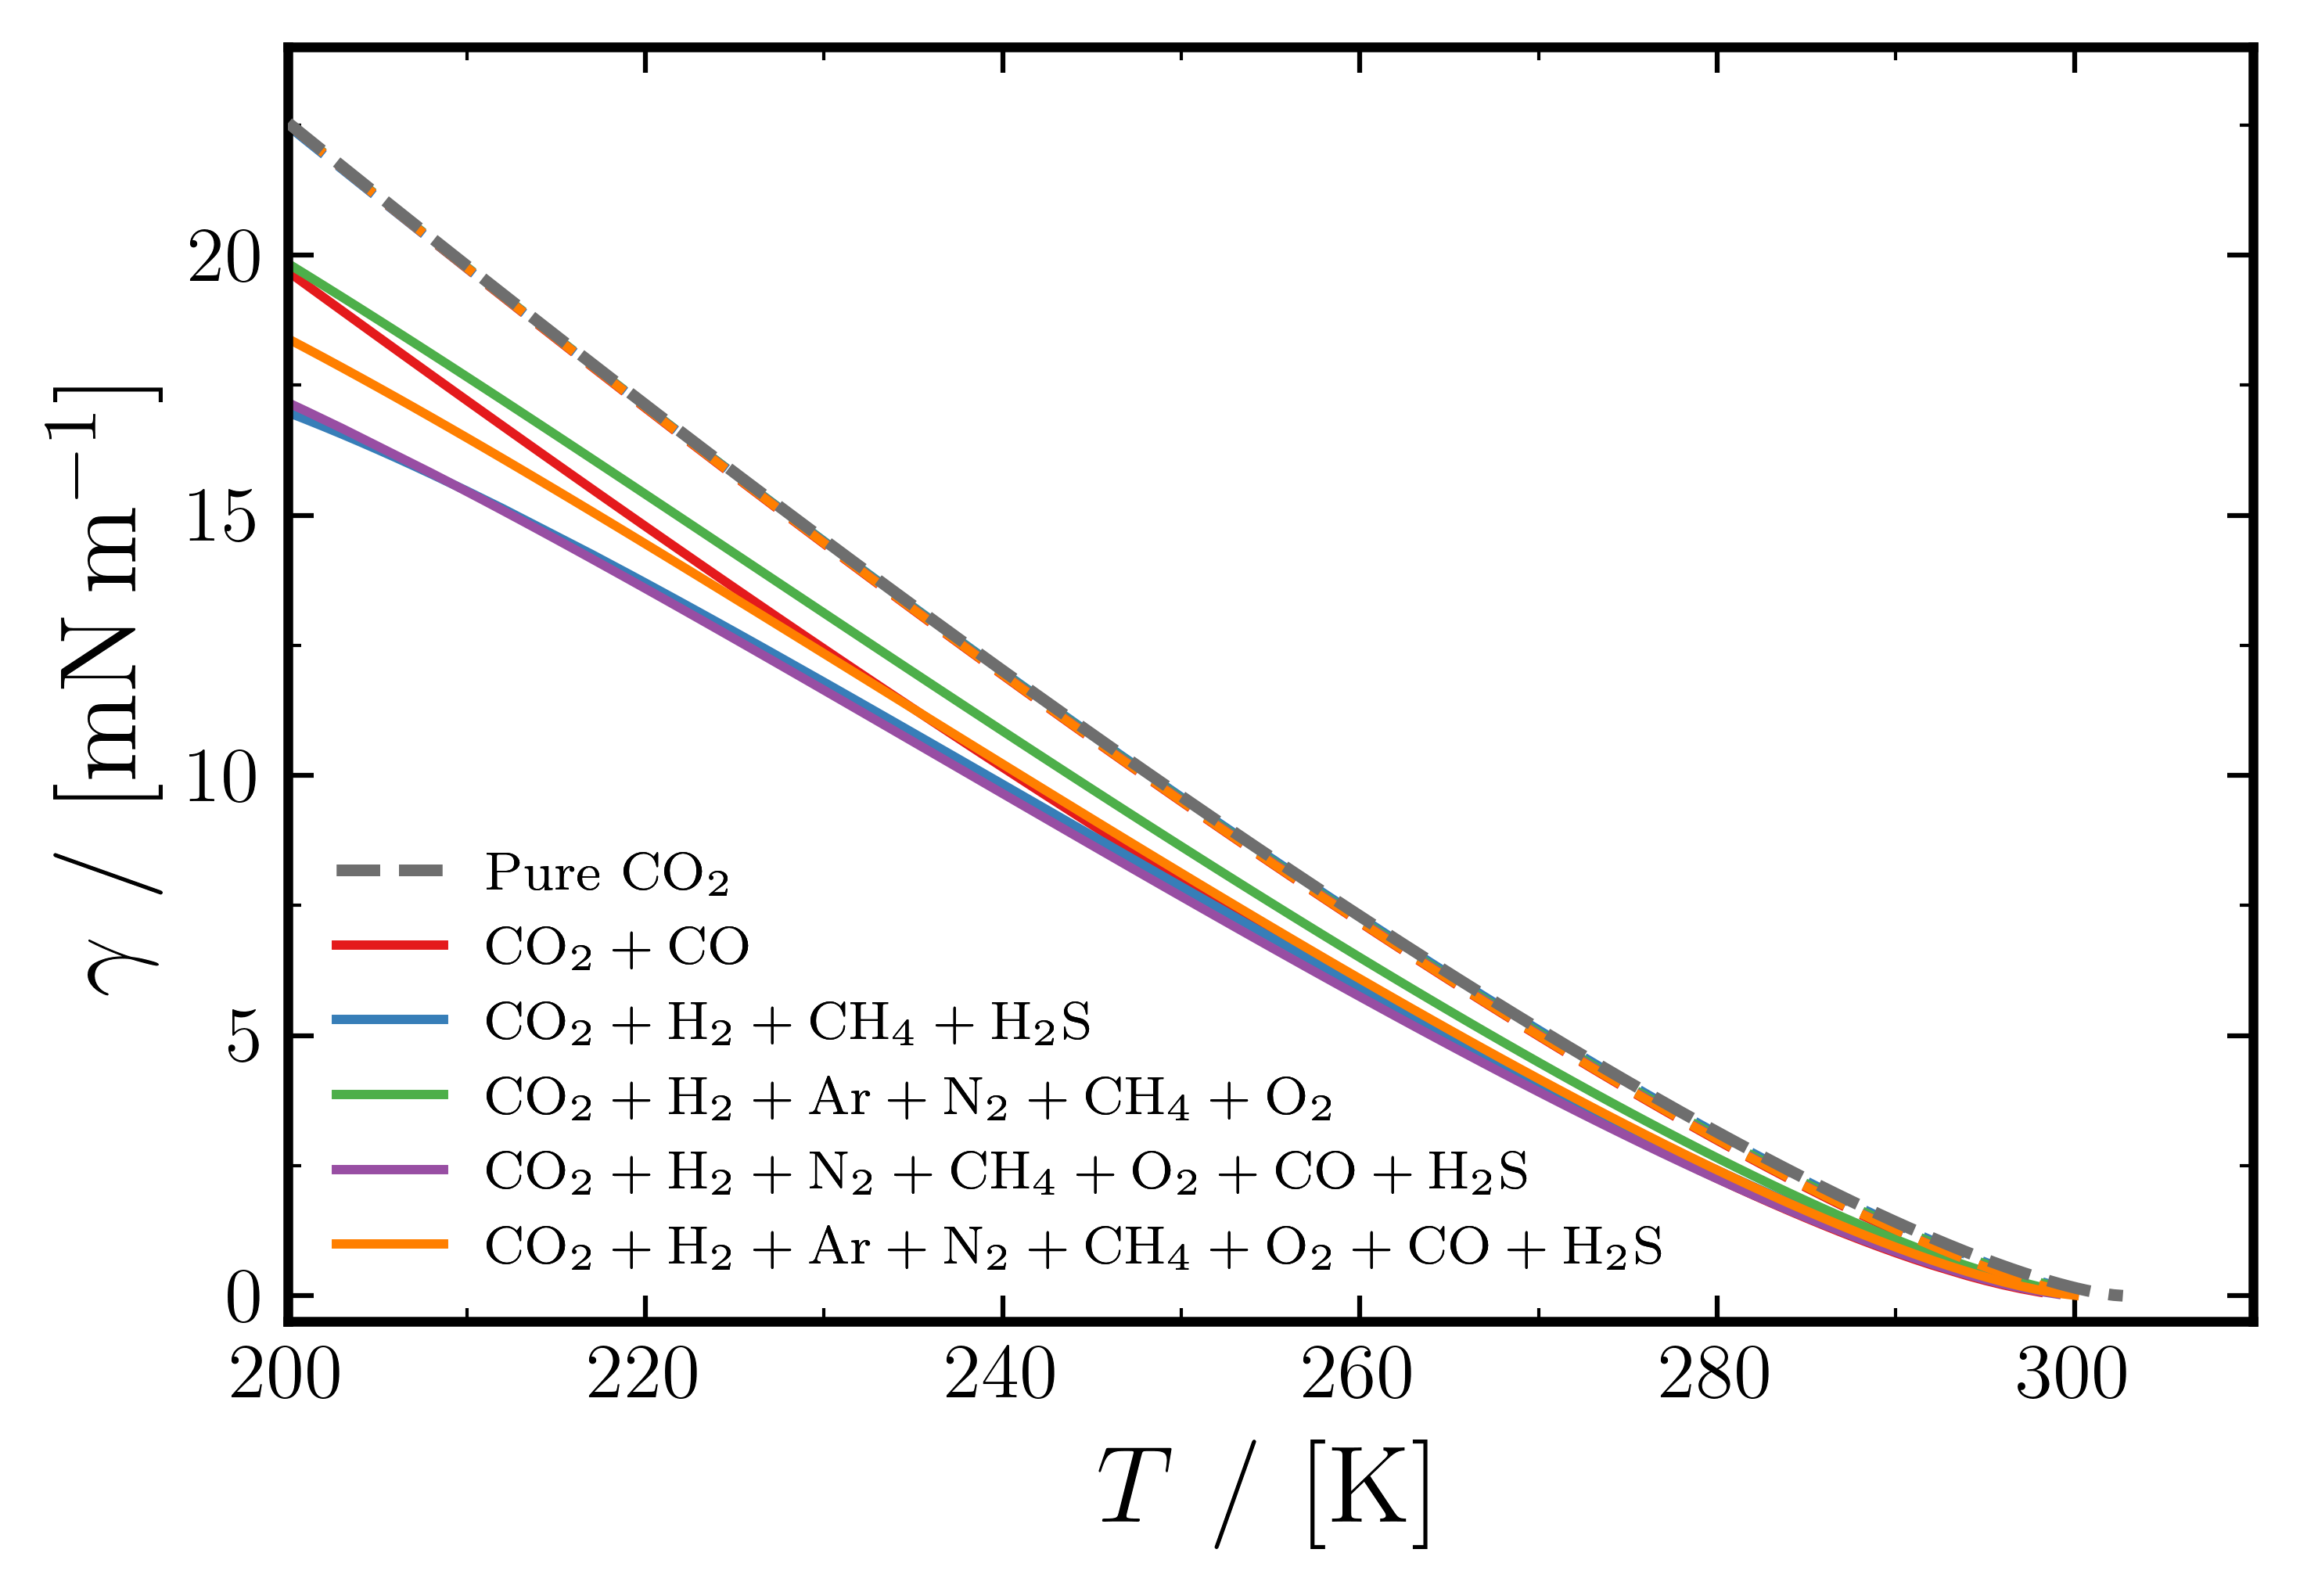

In [4]:
_rp_pure  = pd.read_csv('CO2_REFPROP.csv')
_rp_pure.columns = [c.strip() for c in _rp_pure.columns]
_pcs_pure = pd.read_csv('CO2_pcsaft_saturation.csv')

fig, ax = ps.plot_init(w=5.0, h=3.5)

# Pure CO2 references first (rendered under the mixture curves)
# ax.plot(_rp_pure['T(K)'],  _rp_pure['sigma(mN/m)'],
#         color='#2ca02c', lw=1.8, ls='-',         zorder=3)
ax.plot(_pcs_pure['T_K'],  _pcs_pure['gamma_mN_m'],
        color='#6e6e6e', lw=1.8, ls='--', zorder=3)

for k, color in zip(TASK_IDS, COLORS):
    bub = ift_bubble[k].dropna(subset=['gamma']).sort_values('temperature')
    dew = ift_dew[k].dropna(subset=['gamma']).sort_values('temperature')
    ax.plot(bub['temperature'], bub['gamma'], color=color, lw=1.4, ls='-')
    ax.plot(dew['temperature'], dew['gamma'], color=color, lw=1.4, ls=(0, (5, 2)))

# Mixture legend: pure-CO2 (two models) + mixtures
mix_handles = [
    mlines.Line2D([], [], color="#6e6e6e", lw=1.8, ls='--',
                 label=r"$\mathrm{Pure}\ \mathrm{CO}_2$"),] + [
    mlines.Line2D([], [], color=color, lw=1.4, ls='-', label=labels[k])
    for k, color in zip(TASK_IDS, COLORS)
]
branch_handles = [
    # mlines.Line2D([], [], color='black', lw=1.4, ls='-',           label='bubble'),
    # mlines.Line2D([], [], color='black', lw=1.4, ls=(0, (5, 2)),   label='dew'),
]

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',               fontsize=ps.label_fontsize*1.2)
ax.set_ylabel(r'$\gamma$ $/$ $[\mathrm{mN\,m^{-1}}]$', fontsize=ps.label_fontsize*1.2)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True, labelsize=ps.tick_labelsize*1.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

leg_mix = ax.legend(handles=mix_handles, fontsize=ps.label_fontsize/1.7, ncol=1,
                    loc='lower left', frameon=False, handlelength=2.0)
ax.add_artist(leg_mix)
# ax.legend(handles=branch_handles, fontsize=ps.label_fontsize/1.6, loc='lower left',
#           frameon=False, handlelength=3.0)

plt.xlim(200, 310)
plt.ylim(-0.5, 24)
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_gamma_vs_T_hires')
plt.show()

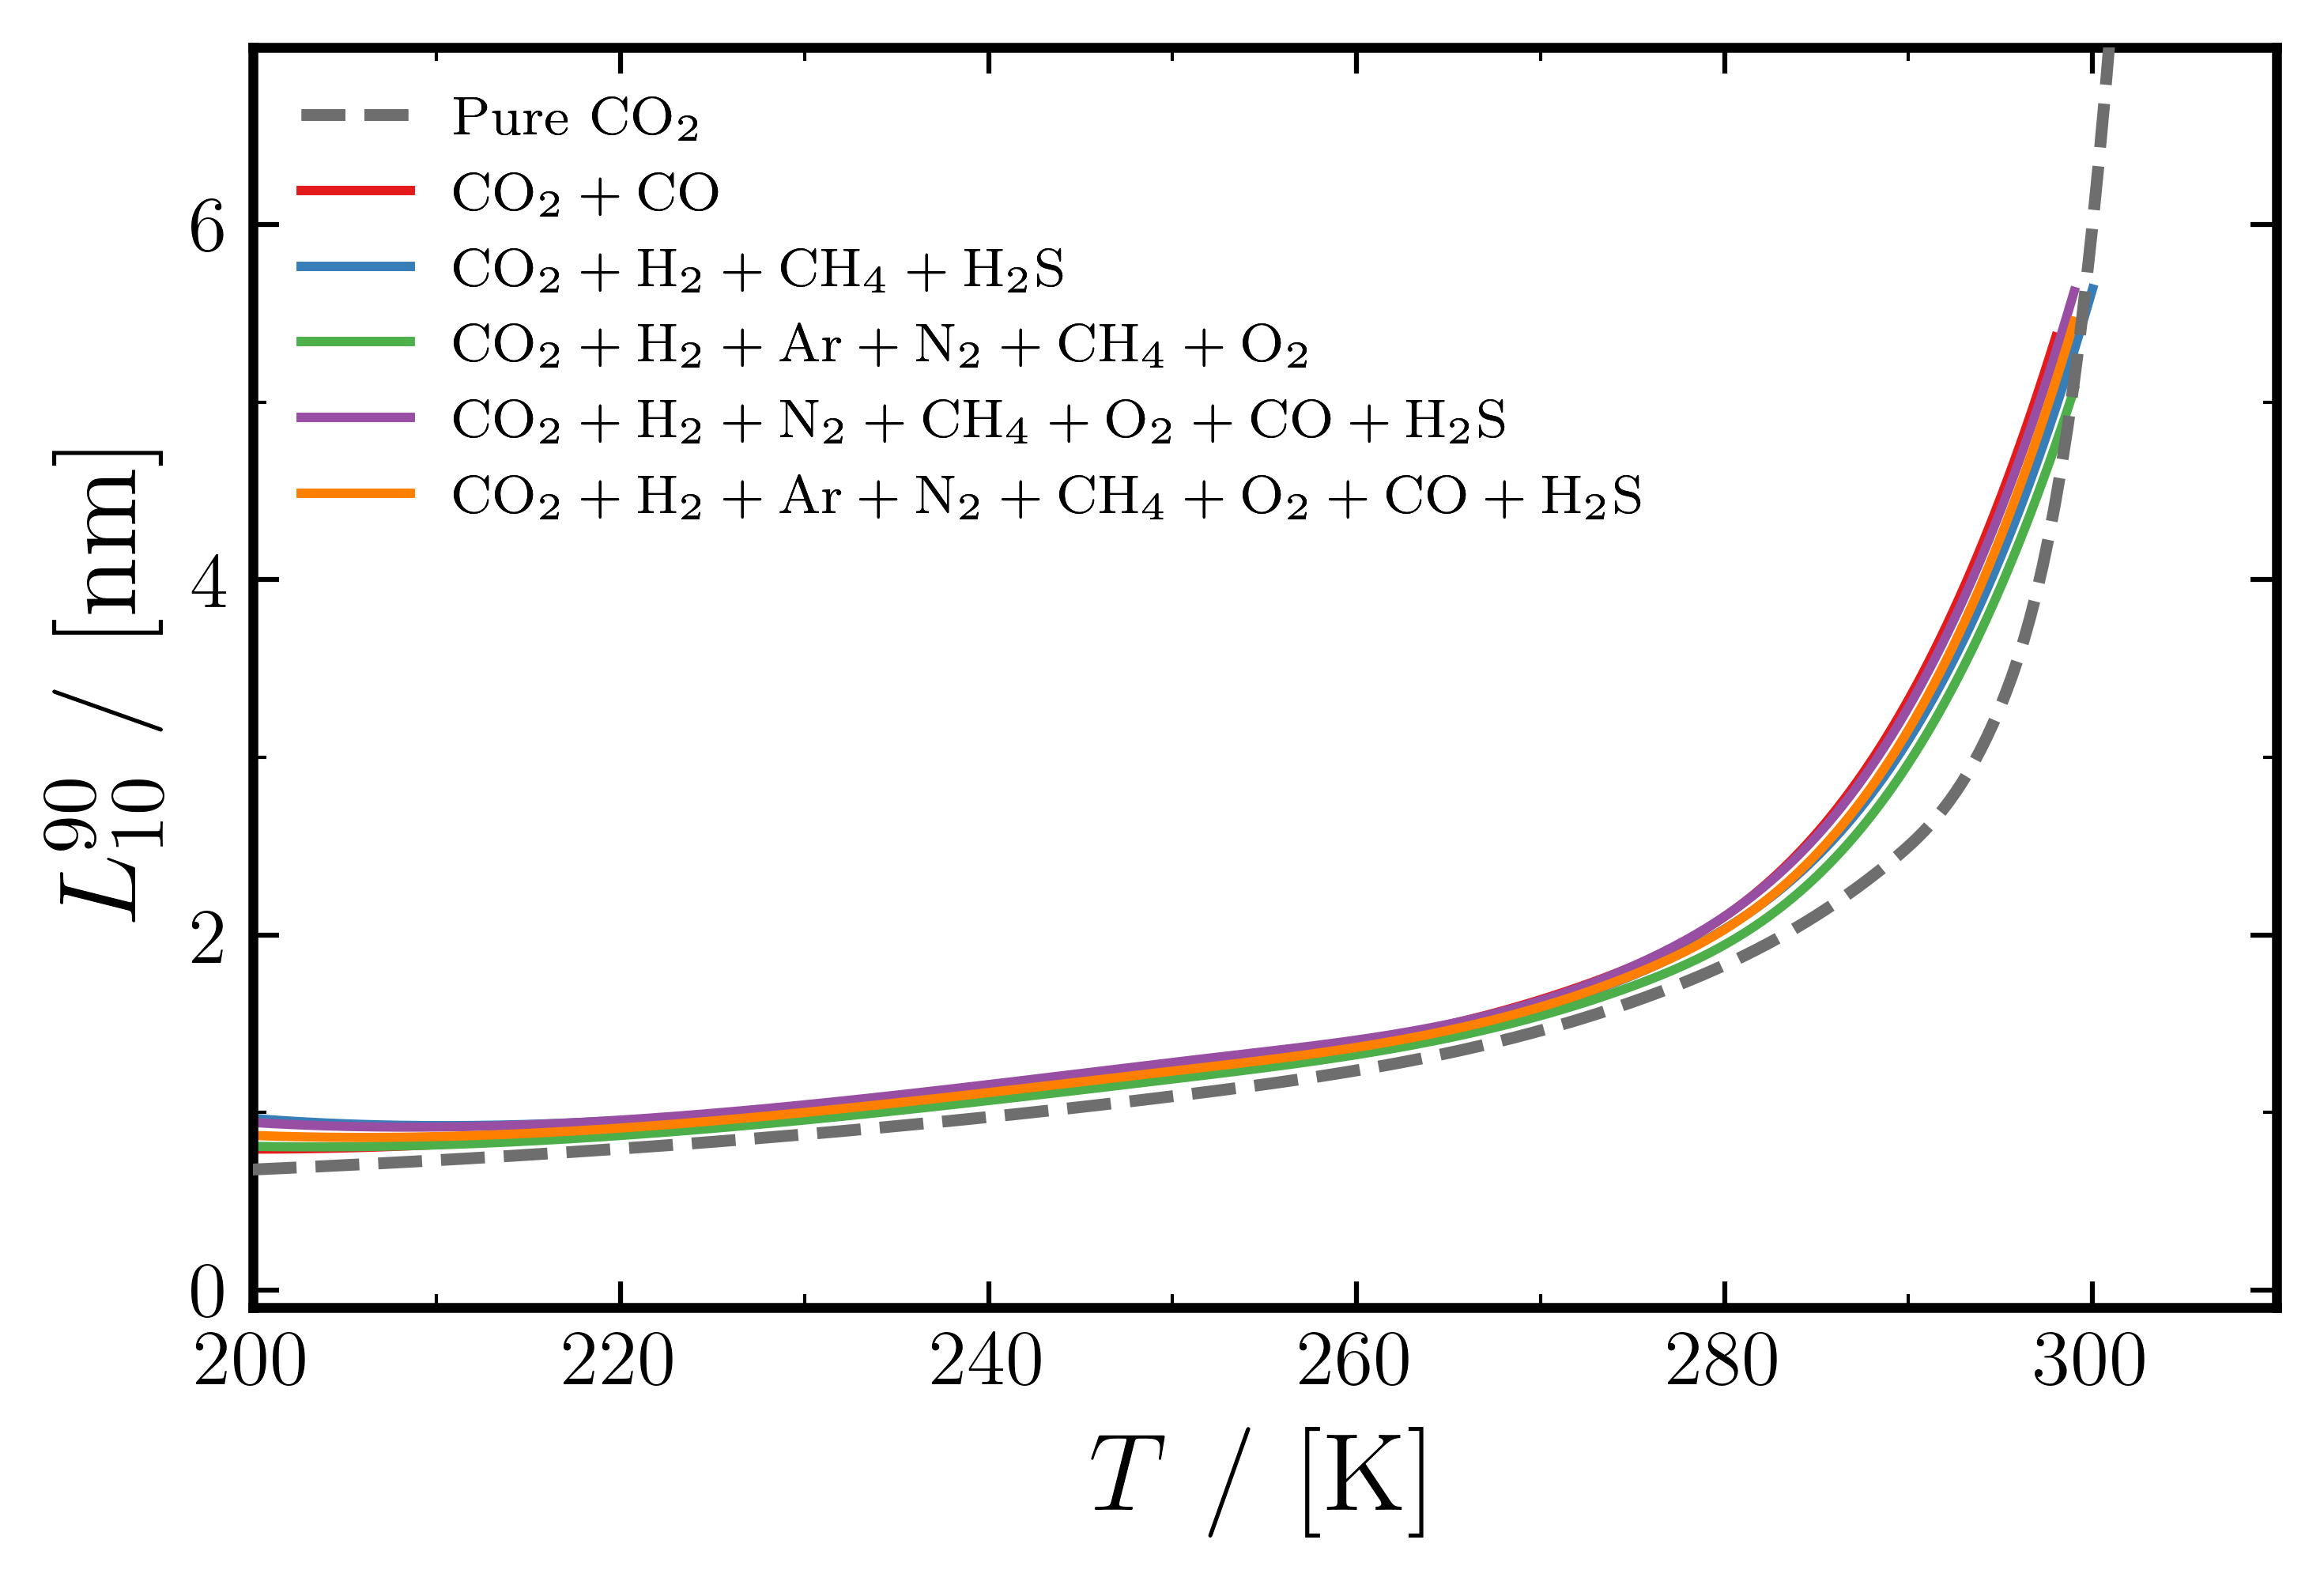

In [9]:


def _fit_critical_amplitude(T, L, Tc, exponent=0.5, t_min=1e-3):
    """Fit L = A * (1 - T/Tc)^(-exponent), median over the tail (outlier-robust)."""
    T = np.asarray(T); L = np.asarray(L)
    t = 1.0 - T / Tc
    valid = (t > t_min) & (L > 0)
    if not valid.any():
        return None
    log_A = np.log(L[valid]) + exponent * np.log(t[valid])
    return float(np.exp(np.median(log_A)))

def _extrapolate(T_last, Tc, A, exponent=0.5, t_min_eps=2e-4, n=80):
    """Generate the divergent tail L = A * (1 - T/Tc)^(-exp) from T_last → Tc⁻."""
    T_ext = np.linspace(T_last, Tc * (1 - t_min_eps), n)
    L_ext = A * (1.0 - T_ext / Tc) ** (-exponent)
    return T_ext, L_ext

def _smooth_curve(T, L, s_per_pt=0.001, n_dense=300):
    """Cubic smoothing spline. Returns dense (T, L) that hides numerical jitter.
    s_per_pt scales the smoothing budget by len(T) * mean(L)^2 so the value
    is data-magnitude-invariant. With s_per_pt=0.001 max|residual| stays
    under ~0.2 nm for the V6 thickness data."""
    T = np.asarray(T); L = np.asarray(L)
    if len(T) < 4:
        return T, L
    s = s_per_pt * len(T) * (float(np.mean(L)) ** 2)
    try:
        spl = UnivariateSpline(T, L, k=3, s=s)
        T_dense = np.linspace(T[0], T[-1], n_dense)
        return T_dense, spl(T_dense)
    except Exception:
        return T, L

N_TAIL_FIT = 10

fig, ax = ps.plot_init(w=5.0, h=3.5)

# Pure-CO2 reference (PC-SAFT, no REFPROP available for L90_10)
_pc_thick = pd.read_csv('CO2_pcsaft.csv')
_pc_thick.columns = [c.strip() for c in _pc_thick.columns]
_pc_thick = _pc_thick.dropna(subset=['delta(A)'])
_pc_thick = _pc_thick[_pc_thick['delta(A)'] > 0].sort_values('T(K)')
T_pure = _pc_thick['T(K)'].to_numpy()
L_pure = _pc_thick['delta(A)'].to_numpy() / 10.0       # Å → nm
Tc_pure_PC = float(_pcs_pure['T_K'].iloc[-1])           # from prev cell

T_pure_s, L_pure_s = _smooth_curve(T_pure, L_pure)
ax.plot(T_pure_s, L_pure_s, color='#6e6e6e', lw=1.8, ls='--', zorder=3)
# A_pure = _fit_critical_amplitude(T_pure[-N_TAIL_FIT:], L_pure[-N_TAIL_FIT:], Tc_pure_PC)
# if A_pure is not None:
#     T_ex, L_ex = _extrapolate(T_pure[-1], Tc_pure_PC, A_pure)
#     ax.plot(T_ex, L_ex, color='#6e6e6e', lw=1.0, ls=':', alpha=0.8, zorder=3)

# Mixtures — bubble branch only
for k, color in zip(TASK_IDS, COLORS):
    sub = ift_bubble[k].dropna(subset=['interfacial_thickness'])
    sub = sub[sub['interfacial_thickness'] > 0].sort_values('temperature')
    T = sub['temperature'].to_numpy()
    L = sub['interfacial_thickness'].to_numpy()
    T_s, L_s = _smooth_curve(T, L)
    ax.plot(T_s, L_s, color=color, lw=1.4, ls='-')

    # if len(T) >= N_TAIL_FIT:
    #     A = _fit_critical_amplitude(T[-N_TAIL_FIT:], L[-N_TAIL_FIT:], Tc_K[k])
    #     if A is not None:
    #         T_ex, L_ex = _extrapolate(T[-1], Tc_K[k], A)
    #         ax.plot(T_ex, L_ex, color=color, lw=0.9, ls=':', alpha=0.7)

# Legends — mixture identity + branch style + extrapolation note
mix_handles = [
    mlines.Line2D([], [], color='#6e6e6e', lw=1.8, ls='--', label=r"$\mathrm{Pure}\ \mathrm{CO}_2$"),] + [
    mlines.Line2D([], [], color=color, lw=1.4, ls='-', label=labels[k])
    for k, color in zip(TASK_IDS, COLORS)
]
branch_handles = [
    # mlines.Line2D([], [], color='black', lw=1.4, ls='-',         label='bubble'),
    # mlines.Line2D([], [], color='black', lw=1.4, ls=(0, (5, 2)), label='dew'),
    # mlines.Line2D([], [], color='black', lw=0.9, ls=':',         label=r'$\propto (1-T/T_c)^{-1/2}$'),
]

ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$',            fontsize=ps.label_fontsize*1.2)
ax.set_ylabel(r'$L^{90}_{10}$ $/$ $[\mathrm{nm}]$', fontsize=ps.label_fontsize*1.2)

ps.apply_axis_style(ax)
ax.tick_params(axis='both', which='major', bottom=True, top=True,
               left=True, right=True, labelsize=ps.tick_labelsize*1.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

leg_mix = ax.legend(handles=mix_handles, fontsize=ps.label_fontsize/1.7, ncol=1,
                    loc='upper left', frameon=False, handlelength=2.0)
ax.add_artist(leg_mix)
# ax.legend(handles=branch_handles, fontsize=7, loc='center left',
#           frameon=False, handlelength=3.0)

plt.xlim(200, 310)
plt.ylim(-0.1, 7)             # let divergent tails run off the top
plt.tight_layout()
ps.save_plot(fig, 'sensitivity_thickness_vs_T_hires')
plt.show()

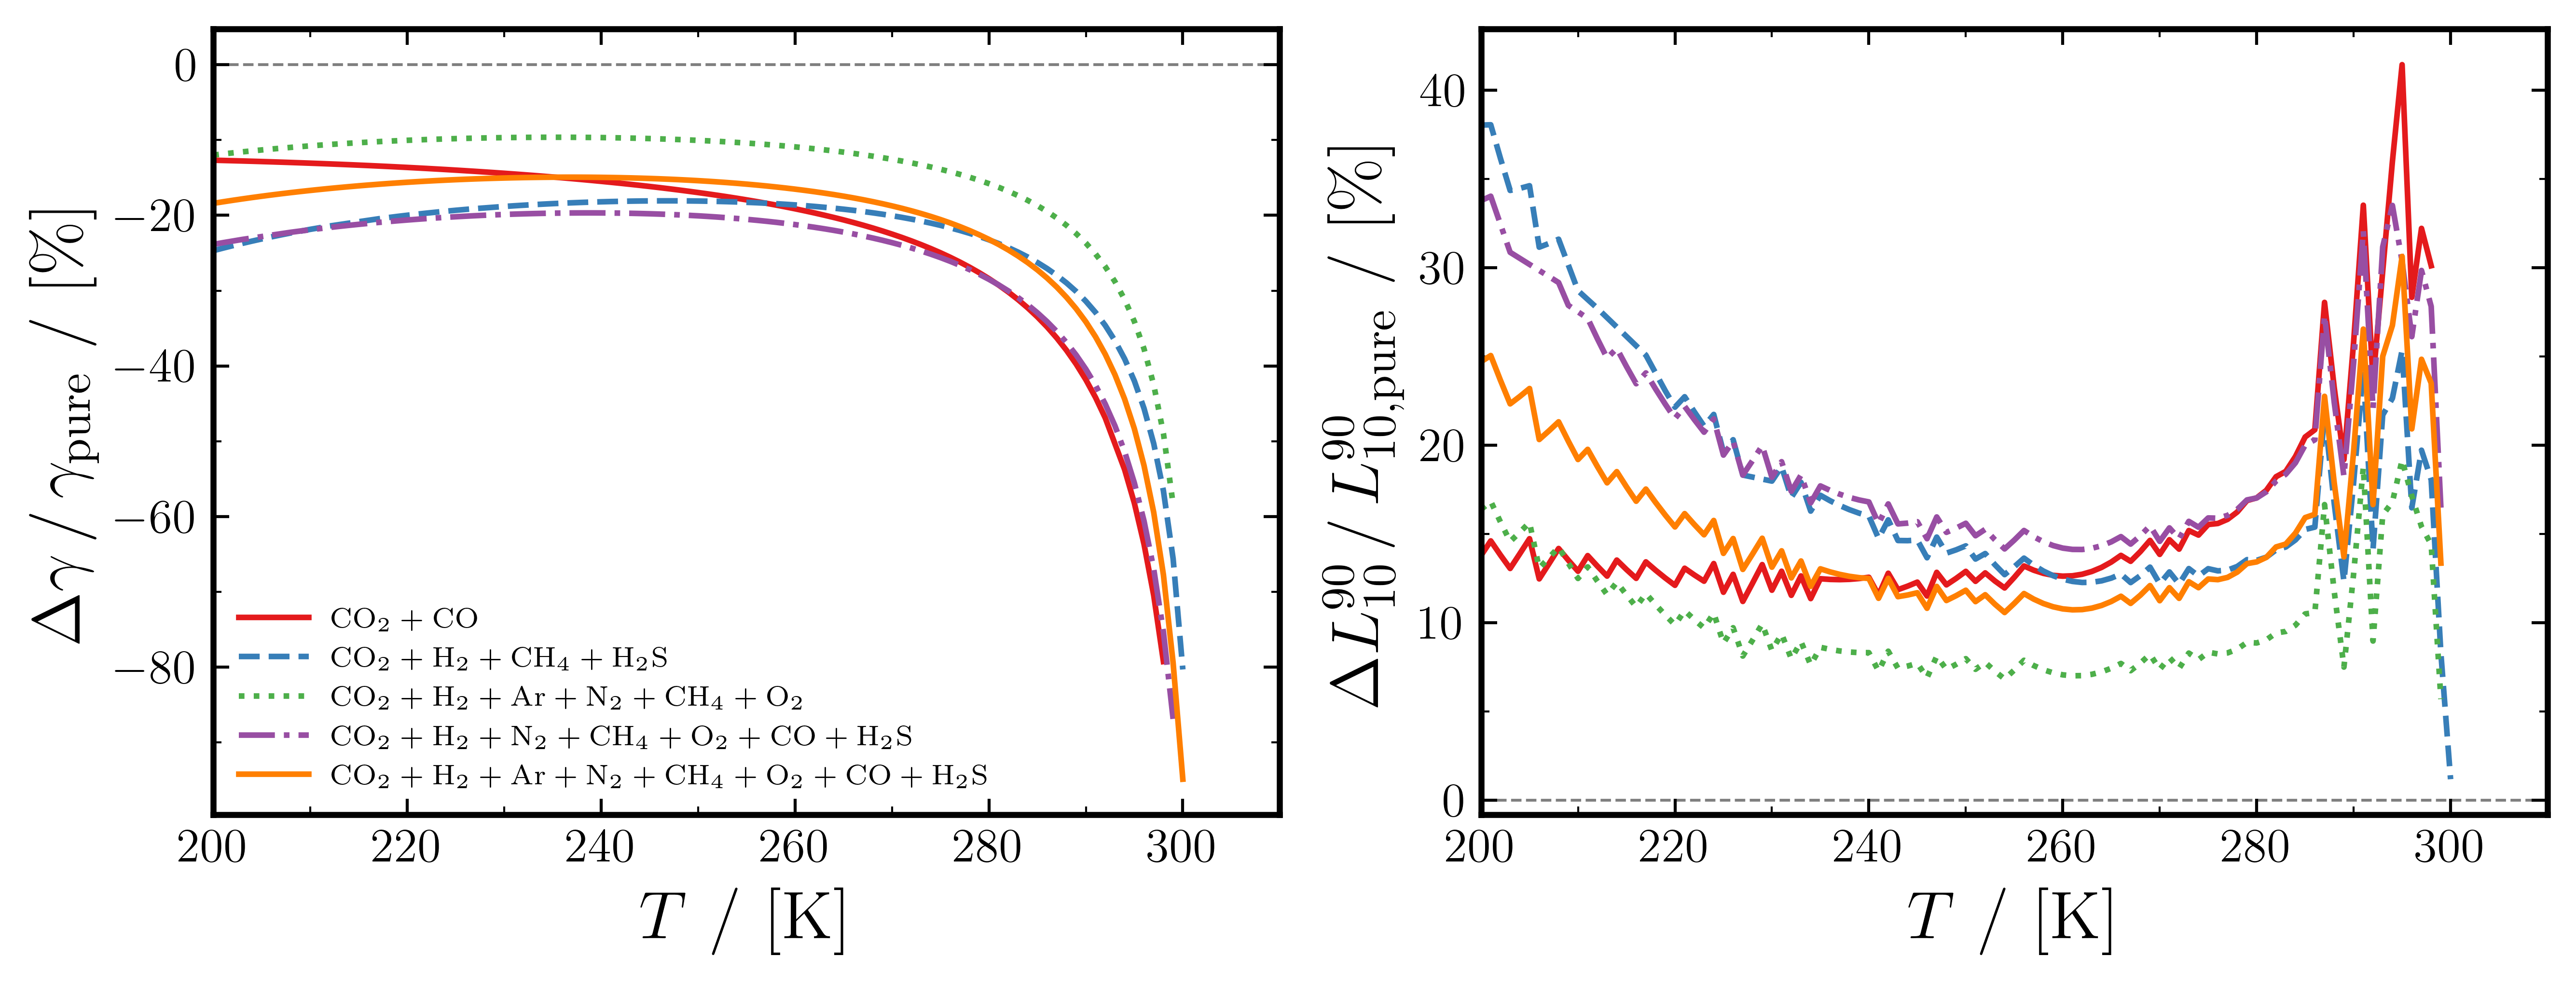

In [6]:
# ── Plot 4: Mixture deviation from pure CO2 — PC-SAFT only ─────────
# For each mixture (bubble branch), interpolate pure-CO2 PC-SAFT γ and
# L90_10 at the same temperatures, then compute the relative deviation:
#   Δγ / γ_pure [%]     and     ΔL / L_pure [%]
# Bubble branch only (liquid-side saturated conditions).
# Points outside the pure-CO2 T range are masked (NaN from interp).

from scipy.interpolate import interp1d

# Build cubic interpolants from pure-CO2 PC-SAFT reference data
_gamma_interp = interp1d(
    _pcs_pure['T_K'].to_numpy(), _pcs_pure['gamma_mN_m'].to_numpy(),
    kind='cubic', bounds_error=False, fill_value=np.nan,
)
_thick_interp = interp1d(
    _pc_thick['T(K)'].to_numpy(), _pc_thick['delta(A)'].to_numpy() / 10.0,  # Å → nm
    kind='cubic', bounds_error=False, fill_value=np.nan,
)

fig, (ax1, ax2) = ps.plot_init_multi(nrows=1, ncols=2, w=9.0, h=3.5)

for k, color in zip(TASK_IDS, COLORS):
    # γ relative deviation
    bub_g = ift_bubble[k].dropna(subset=['gamma']).sort_values('temperature')
    T_g   = bub_g['temperature'].to_numpy()
    g_mix = bub_g['gamma'].to_numpy()
    g_ref = _gamma_interp(T_g)
    mask  = np.isfinite(g_ref) & (g_ref > 0)
    ax1.plot(T_g[mask], (g_mix[mask] - g_ref[mask]) / g_ref[mask] * 100.0,
             color=color, lw=1.4, label=labels[k])

    # L90_10 relative deviation
    bub_l = ift_bubble[k].dropna(subset=['interfacial_thickness'])
    bub_l = bub_l[bub_l['interfacial_thickness'] > 0].sort_values('temperature')
    T_l   = bub_l['temperature'].to_numpy()
    l_mix = bub_l['interfacial_thickness'].to_numpy()
    l_ref = _thick_interp(T_l)
    mask  = np.isfinite(l_ref) & (l_ref > 0)
    ax2.plot(T_l[mask], (l_mix[mask] - l_ref[mask]) / l_ref[mask] * 100.0,
             color=color, lw=1.4)

for ax in (ax1, ax2):
    ax.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
    ps.apply_axis_style(ax)
    ax.tick_params(axis='both', which='major', bottom=True, top=True,
                   left=True, right=True, labelsize=ps.tick_labelsize*1.2)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_xlim(200, 310)
    ax.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$', fontsize=ps.label_fontsize*1.2)

ax1.set_ylabel(r'$\Delta\gamma\,/\,\gamma_{\mathrm{pure}}$ $/$ $[\%]$',
               fontsize=ps.label_fontsize*1.2)
ax2.set_ylabel(r'$\Delta L^{90}_{10}\,/\,L^{90}_{10,\mathrm{pure}}$ $/$ $[\%]$',
               fontsize=ps.label_fontsize*1.2)

ax1.legend(fontsize=7, frameon=False, handlelength=2.5, loc='best')

fig.tight_layout()
ps.save_plot(fig, 'sensitivity_deviation_from_pure_co2')
plt.show()

In [7]:
# ── Metrics: mixture deviation from pure CO2 (PC-SAFT) ─────────────
# One row per mixture; columns:
#   MRD_γ      : mean relative deviation of γ vs pure CO2 [%]  (signed — bias direction)
#   maxΔγ      : largest |Δγ/γ_pure| [%]
#   T@maxΔγ    : temperature at which that maximum occurs [K]
#   MRD_L      : mean relative deviation of L90_10 [%]
#   maxΔL      : largest |ΔL/L_pure| [%]
#   T@maxΔL    : temperature at that maximum [K]

rows = []
for k in TASK_IDS:
    # ── γ ──────────────────────────────────────────────────────────
    bub_g = ift_bubble[k].dropna(subset=['gamma']).sort_values('temperature')
    T_g   = bub_g['temperature'].to_numpy()
    g_mix = bub_g['gamma'].to_numpy()
    g_ref = _gamma_interp(T_g)
    mask  = np.isfinite(g_ref) & (g_ref > 0)
    T_g, g_mix, g_ref = T_g[mask], g_mix[mask], g_ref[mask]
    rel_g  = (g_mix - g_ref) / g_ref * 100.0
    mrd_g  = float(np.mean(rel_g))
    idx_g  = int(np.argmax(np.abs(rel_g)))

    # ── L90_10 ─────────────────────────────────────────────────────
    bub_l = ift_bubble[k].dropna(subset=['interfacial_thickness'])
    bub_l = bub_l[bub_l['interfacial_thickness'] > 0].sort_values('temperature')
    T_l   = bub_l['temperature'].to_numpy()
    l_mix = bub_l['interfacial_thickness'].to_numpy()
    l_ref = _thick_interp(T_l)
    mask  = np.isfinite(l_ref) & (l_ref > 0)
    T_l, l_mix, l_ref = T_l[mask], l_mix[mask], l_ref[mask]
    rel_l  = (l_mix - l_ref) / l_ref * 100.0
    mrd_l  = float(np.mean(rel_l))
    idx_l  = int(np.argmax(np.abs(rel_l)))

    rows.append({
        'mixture':   labels[k],
        'n_comp':    int(feeds.iloc[k]['mixture_size']),
        'MRD_γ [%]':     round(mrd_g, 2),
        'max|Δγ/γ| [%]': round(float(rel_g[idx_g]), 2),
        'T @ max Δγ [K]': round(float(T_g[idx_g]), 1),
        'MRD_L [%]':     round(mrd_l, 2),
        'max|ΔL/L| [%]': round(float(rel_l[idx_l]), 2),
        'T @ max ΔL [K]': round(float(T_l[idx_l]), 1),
    })

metrics_df = pd.DataFrame(rows).set_index('mixture')
metrics_df.to_csv('sensitivity_mixture_deviation_metrics.csv', float_format='%.2f')

print('Mixture deviation from pure CO2 PC-SAFT (bubble branch)\n')
print(metrics_df.to_string())
print('\nSaved → sensitivity_mixture_deviation_metrics.csv')

Mixture deviation from pure CO2 PC-SAFT (bubble branch)

                                                                                                            n_comp  MRD_γ [%]  max|Δγ/γ| [%]  T @ max Δγ [K]  MRD_L [%]  max|ΔL/L| [%]  T @ max ΔL [K]
mixture                                                                                                                                                                                               
$\mathrm{CO_2}+\mathrm{CO}$                                                                                      2     -21.79         -79.24           298.0      15.35          41.44           295.0
$\mathrm{CO_2}+\mathrm{H_2}+\mathrm{CH_4}+\mathrm{H_2S}$                                                         4     -23.72         -80.29           300.0      17.71          38.06           201.0
$\mathrm{CO_2}+\mathrm{H_2}+\mathrm{Ar}+\mathrm{N_2}+\mathrm{CH_4}+\mathrm{O_2}$                                 6     -14.13         -58.38       

Pure-CO2  PC-SAFT vs REFPROP
  density/gamma window : T <= 297.7 K   (= min(Tc_RP=304.13, Tc_PC=302.71) - 5 K)
  P_sat window         : T <  304.08 K   (REFPROP undefined above its Tc)

  property            n        RMSE        MAE     MAPE
  ---------------- ---- ----------- ---------- --------
  P_sat  [bar]      200      1.8679     1.5217    7.15%
  gamma  [mN/m]      98      0.9965     0.7782    8.25%
  rho_l  [kg/m^3]    98     16.2598    12.4857    1.35%
  rho_v  [kg/m^3]    98      6.7651     4.5753    7.14%

Saved -> CO2_pcsaft_vs_refprop_rmse.csv


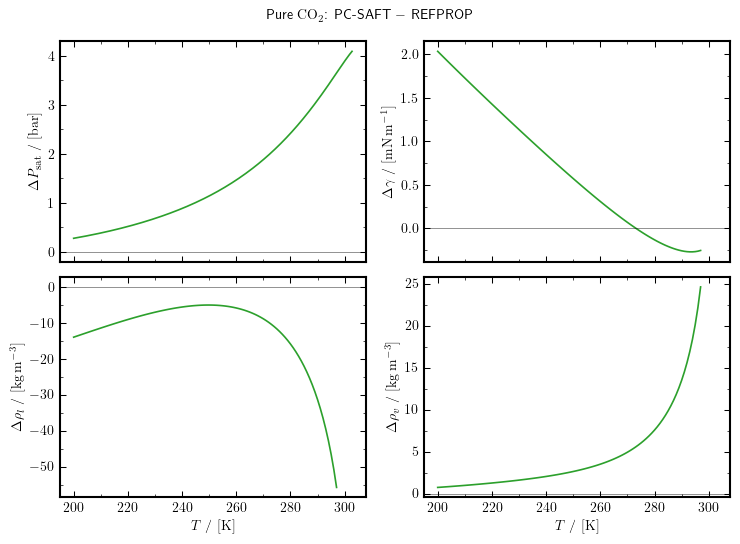

In [8]:
_pc_props = pd.read_csv('CO2_pcsaft.csv')
_rp_props = pd.read_csv('CO2_REFPROP.csv')
_pc_sat   = pd.read_csv('CO2_pcsaft_saturation.csv')
_pc_props.columns = [c.strip() for c in _pc_props.columns]
_rp_props.columns = [c.strip() for c in _rp_props.columns]

# gamma, rho_l, rho_v: inner join on T (both share the same T grid)
_merged = pd.merge(_rp_props, _pc_props, on='T(K)', suffixes=('_RP', '_PC')).dropna()

# P_sat: pair PC-SAFT continuous saturation curve with REFPROP @ same T
Tc_RP_K = CP.PropsSI('TCRIT', 'CO2')                              # ~304.13 K
Tc_PC_K = float(_pc_sat['T_K'].iloc[-1])                          # ~302.71 K
_psat = _pc_sat[_pc_sat['T_K'] < Tc_RP_K - 0.05].copy()
_psat['P_bar_RP'] = [CP.PropsSI('P', 'T', float(T), 'Q', 0, 'CO2') / 1e5
                     for T in _psat['T_K']]
_psat = _psat.rename(columns={'P_bar': 'P_bar_PC'})

# Density/gamma comparison: stay sub-critical for both EOS (avoids divergence near Tc)
T_SAFE_K = min(Tc_RP_K, Tc_PC_K) - 5.0
_sub = _merged[_merged['T(K)'] <= T_SAFE_K]

def _rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
def _mae(a, b):  return float(np.mean(np.abs(np.asarray(a) - np.asarray(b))))
def _mape(a, b): return float(np.mean(np.abs((np.asarray(a) - np.asarray(b)) / np.asarray(a))) * 100)

rmse_table = [
    ('P_sat  [bar]',    len(_psat),
     _rmse(_psat['P_bar_RP'],  _psat['P_bar_PC']),
     _mae (_psat['P_bar_RP'],  _psat['P_bar_PC']),
     _mape(_psat['P_bar_RP'],  _psat['P_bar_PC'])),
    ('gamma  [mN/m]',   len(_sub),
     _rmse(_sub['sigma(mN/m)_RP'],  _sub['sigma(mN/m)_PC']),
     _mae (_sub['sigma(mN/m)_RP'],  _sub['sigma(mN/m)_PC']),
     _mape(_sub['sigma(mN/m)_RP'],  _sub['sigma(mN/m)_PC'])),
    ('rho_l  [kg/m^3]', len(_sub),
     _rmse(_sub['rho_l(kg/m3)_RP'], _sub['rho_l(kg/m3)_PC']),
     _mae (_sub['rho_l(kg/m3)_RP'], _sub['rho_l(kg/m3)_PC']),
     _mape(_sub['rho_l(kg/m3)_RP'], _sub['rho_l(kg/m3)_PC'])),
    ('rho_v  [kg/m^3]', len(_sub),
     _rmse(_sub['rho_v(kg/m3)_RP'], _sub['rho_v(kg/m3)_PC']),
     _mae (_sub['rho_v(kg/m3)_RP'], _sub['rho_v(kg/m3)_PC']),
     _mape(_sub['rho_v(kg/m3)_RP'], _sub['rho_v(kg/m3)_PC'])),
]

print(f'Pure-CO2  PC-SAFT vs REFPROP')
print(f'  density/gamma window : T <= {T_SAFE_K:.1f} K   (= min(Tc_RP={Tc_RP_K:.2f}, Tc_PC={Tc_PC_K:.2f}) - 5 K)')
print(f'  P_sat window         : T <  {Tc_RP_K-0.05:.2f} K   (REFPROP undefined above its Tc)')
print()
print(f'  {"property":<16} {"n":>4} {"RMSE":>11} {"MAE":>10} {"MAPE":>8}')
print(f'  {"-"*16} {"-"*4} {"-"*11} {"-"*10} {"-"*8}')
for name, n, rmse_v, mae_v, mape_v in rmse_table:
    print(f'  {name:<16} {n:>4d} {rmse_v:>11.4f} {mae_v:>10.4f} {mape_v:>7.2f}%')

rmse_df = pd.DataFrame(rmse_table,
                       columns=['property', 'n', 'RMSE', 'MAE', 'MAPE_%'])
rmse_df.to_csv('CO2_pcsaft_vs_refprop_rmse.csv', index=False, float_format='%.4f')
print('\nSaved -> CO2_pcsaft_vs_refprop_rmse.csv')

# ── Residual plot (PC-SAFT - REFPROP) for all four properties ─────
fig, axes = plt.subplots(2, 2, figsize=(7.5, 5.5), sharex=True)
(ax_p, ax_g), (ax_l, ax_v) = axes

ax_p.plot(_psat['T_K'], _psat['P_bar_PC'] - _psat['P_bar_RP'], color='#2ca02c', lw=1.2)
ax_p.set_ylabel(r'$\Delta P_\mathrm{sat}$ $/$ $[\mathrm{bar}]$')

ax_g.plot(_sub['T(K)'], _sub['sigma(mN/m)_PC'] - _sub['sigma(mN/m)_RP'], color='#2ca02c', lw=1.2)
ax_g.set_ylabel(r'$\Delta \gamma$ $/$ $[\mathrm{mN\,m^{-1}}]$')

ax_l.plot(_sub['T(K)'], _sub['rho_l(kg/m3)_PC'] - _sub['rho_l(kg/m3)_RP'], color='#2ca02c', lw=1.2)
ax_l.set_ylabel(r'$\Delta \rho_l$ $/$ $[\mathrm{kg\,m^{-3}}]$')
ax_l.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$')

ax_v.plot(_sub['T(K)'], _sub['rho_v(kg/m3)_PC'] - _sub['rho_v(kg/m3)_RP'], color='#2ca02c', lw=1.2)
ax_v.set_ylabel(r'$\Delta \rho_v$ $/$ $[\mathrm{kg\,m^{-3}}]$')
ax_v.set_xlabel(r'$T$ $/$ $[\mathrm{K}]$')

for a in axes.flat:
    a.axhline(0, color='k', lw=0.5, alpha=0.6)
    ps.apply_axis_style(a)
    a.xaxis.set_minor_locator(AutoMinorLocator(2))
    a.yaxis.set_minor_locator(AutoMinorLocator(2))

fig.suptitle(r'Pure $\mathrm{CO_2}$:  PC-SAFT $-$ REFPROP', fontsize=10)
fig.tight_layout()
ps.save_plot(fig, 'sensitivity_pure_co2_residuals')
plt.show()